# Module 03 — GCOV HH/HV Backscatter Ratio Analysis

**File used:** `NISAR_L2_PR_GCOV_026_091_D_075_4005_DHDH_A_20260726T123348_20260726T123423_P05023_N_F_J_001.h5`

**Product / band:** GCOV (L2, geocoded covariance), L-band, track 091 / frame 075, descending, acquired 2026-07-26T12:33:48–12:34:23 UTC.

**Why this file:** it's the L-band GCOV sample, and (per `docs/data_inventory.md`) only contains the diagonal covariance terms HHHH and HVHV — no off-diagonal term. That makes it a good vehicle for the simplest dual-pol product (an HH/HV power ratio) while making explicit what it *can't* do (see Scope & Caveats, and Module 06 which uses the S-band GCOV file that does have the off-diagonal term).

**Region:** confirmed below from `boundingPolygon` metadata — northeastern India, the Brahmaputra valley (Assam) rising into Meghalaya/Bhutan Himalaya foothill terrain.

## Scope & Caveats

This notebook demonstrates an **HH/HV backscatter ratio computation and a simple illustrative threshold split**, using one real GCOV product. It is not a validated land-cover classification — no ground truth, reference land-cover map, or field data has been used to choose or check the threshold; the split shown is purely to illustrate how a ratio product could feed a classification step, not a real one.

**True polarimetric decomposition is not attempted in this notebook — see the dedicated cell below explaining why (only diagonal covariance terms are present in this file) and cross-referencing Module 06, where the S-band GCOV file's extra off-diagonal term makes a step beyond a simple ratio possible.**

Geographic language is strictly technical (terrain/elevation/backscatter).

## Theory recap

See **Module 00, Section 6** for the full explanation. In short: surfaces dominated by surface or double-bounce scattering (smooth/bare ground, built structures) tend toward a *higher* HH/HV power ratio; more depolarizing volume scattering (dense vegetation canopy) tends toward a *lower* ratio. That's the prediction we'll compare the ratio map against below -- qualitatively, not as a validated classification (see Scope & Caveats above).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SAMPLE_DATA_DIR = REPO_ROOT / "SampleData"

import numpy as np
import matplotlib.pyplot as plt

from nisar_tools.io import open_product
from nisar_tools import preprocess as prep
from nisar_tools import viz

plt.rcParams["figure.dpi"] = 100

In [2]:
GCOV_L_PATH = SAMPLE_DATA_DIR / "NISAR_L2_PR_GCOV_026_091_D_075_4005_DHDH_A_20260726T123348_20260726T123423_P05023_N_F_J_001.h5"

gcov_l = open_product(GCOV_L_PATH)

print("Product type:        ", gcov_l.product_type)
print(f"Band group:            science/{gcov_l.band_group}/...")
print("Radar band:           ", gcov_l.radar_band)
print("Track / frame:        ", gcov_l.track_number, "/", gcov_l.frame_number)
print("Orbit direction:      ", gcov_l.orbit_pass_direction)
print("Acquisition (UTC):    ", gcov_l.zero_doppler_start_time, "->", gcov_l.zero_doppler_end_time)

terms = gcov_l.list_covariance_terms("A")
print("\nCovariance terms present (frequencyA):", terms)
print("Off-diagonal term (e.g. HHHV) present:", "HHHV" in terms)

bbox = gcov_l.bbox
print("\nRegion (from boundingPolygon metadata, not assumed):")
print(f"  lon {bbox['lon_min']:.2f} to {bbox['lon_max']:.2f} deg E")
print(f"  lat {bbox['lat_min']:.2f} to {bbox['lat_max']:.2f} deg N")
print(f"  polygon vertex elevations {bbox['height_min']:.0f} to {bbox['height_max']:.0f} m")
print(
    "\nThis spans northeastern India: Brahmaputra valley terrain at the lower "
    "elevations, rising into Meghalaya/Bhutan Himalaya foothills at the higher "
    "elevation polygon vertices."
)

Product type:         GCOV
Band group:            science/LSAR/...
Radar band:            L
Track / frame:         91 / 75
Orbit direction:       Descending
Acquisition (UTC):     2026-07-26T12:33:48.000000000 -> 2026-07-26T12:34:23.999342105

Covariance terms present (frequencyA): ['HHHH', 'HVHV']
Off-diagonal term (e.g. HHHV) present: False

Region (from boundingPolygon metadata, not assumed):
  lon 90.25 to 93.44 deg E
  lat 25.41 to 28.15 deg N
  polygon vertex elevations -18 to 5848 m

This spans northeastern India: Brahmaputra valley terrain at the lower elevations, rising into Meghalaya/Bhutan Himalaya foothills at the higher elevation polygon vertices.


## Why no polarimetric decomposition here

`list_covariance_terms` above confirms this file has **only HHHH and HVHV** — the diagonal (power) terms — for both frequency A and B. There is no HHHV (or any other off-diagonal term), because this is a dual-pol (H-transmit) product, and even within dual-pol, this particular sample simply doesn't carry the cross term.

Polarimetric decomposition (even a basic HH-HV correlation coefficient, let alone a full quad-pol decomposition like Cloude-Pottier or Freeman-Durden) requires an off-diagonal covariance term — it is fundamentally a *cross*-channel product, not derivable from the two diagonal power terms alone. With only HHHH and HVHV, the most this data supports is a power ratio between the two channels. **Module 06** uses the S-band GCOV sample file, which does carry the HHHV off-diagonal term, and computes the HH-HV correlation coefficient that this file cannot support — with an explicit side-by-side comparison of what each file's covariance-term set allows.

In [3]:
dset = gcov_l.get_covariance_dataset("HHHH", "A")
n_rows, n_cols = dset.shape
print("Full frequencyA grid shape:", dset.shape)

coords = gcov_l.coordinates("A")
print(f"Geocoded CRS: EPSG:{coords['epsg']}  (UTM zone, meters)")
print(f"x range: {coords['x'].min():.0f} to {coords['x'].max():.0f} m   y range: {coords['y'].min():.0f} to {coords['y'].max():.0f} m")

row_slice, col_slice = prep.center_window(n_rows, n_cols, 2000, 2000)
hhhh = gcov_l.get_covariance_dataset("HHHH", "A")[row_slice, col_slice]
hvhv = gcov_l.get_covariance_dataset("HVHV", "A")[row_slice, col_slice]
print("Window shape:", hhhh.shape)
print(f"Window extent (approx): x [{coords['x'][col_slice][0]:.0f}, {coords['x'][col_slice][-1]:.0f}] m,"
      f" y [{coords['y'][row_slice][-1]:.0f}, {coords['y'][row_slice][0]:.0f}] m")

Full frequencyA grid shape: (34128, 34704)
Geocoded CRS: EPSG:32646  (UTM zone, meters)
x range: 219605 to 566635 m   y range: 2787125 to 3128395 m
Window shape: (2000, 2000)
Window extent (approx): x [383125, 403115] m, y [2947765, 2967755] m


In [4]:
valid_mask = np.isfinite(hhhh) & np.isfinite(hvhv) & (hhhh > 0) & (hvhv > 0)
print(f"Valid pixel fraction in window: {valid_mask.mean():.1%}")

hhhh_db = prep.power_db(np.where(valid_mask, hhhh, np.nan))
hvhv_db = prep.power_db(np.where(valid_mask, hvhv, np.nan))
ratio_db = prep.ratio_db(hhhh, hvhv)
ratio_db = np.where(valid_mask, ratio_db, np.nan)

print(f"HH/HV ratio (dB), valid pixels: min={np.nanmin(ratio_db):.2f}, "
      f"median={np.nanmedian(ratio_db):.2f}, max={np.nanmax(ratio_db):.2f}")

Valid pixel fraction in window: 100.0%


HH/HV ratio (dB), valid pixels: min=-9.62, median=6.94, max=28.48


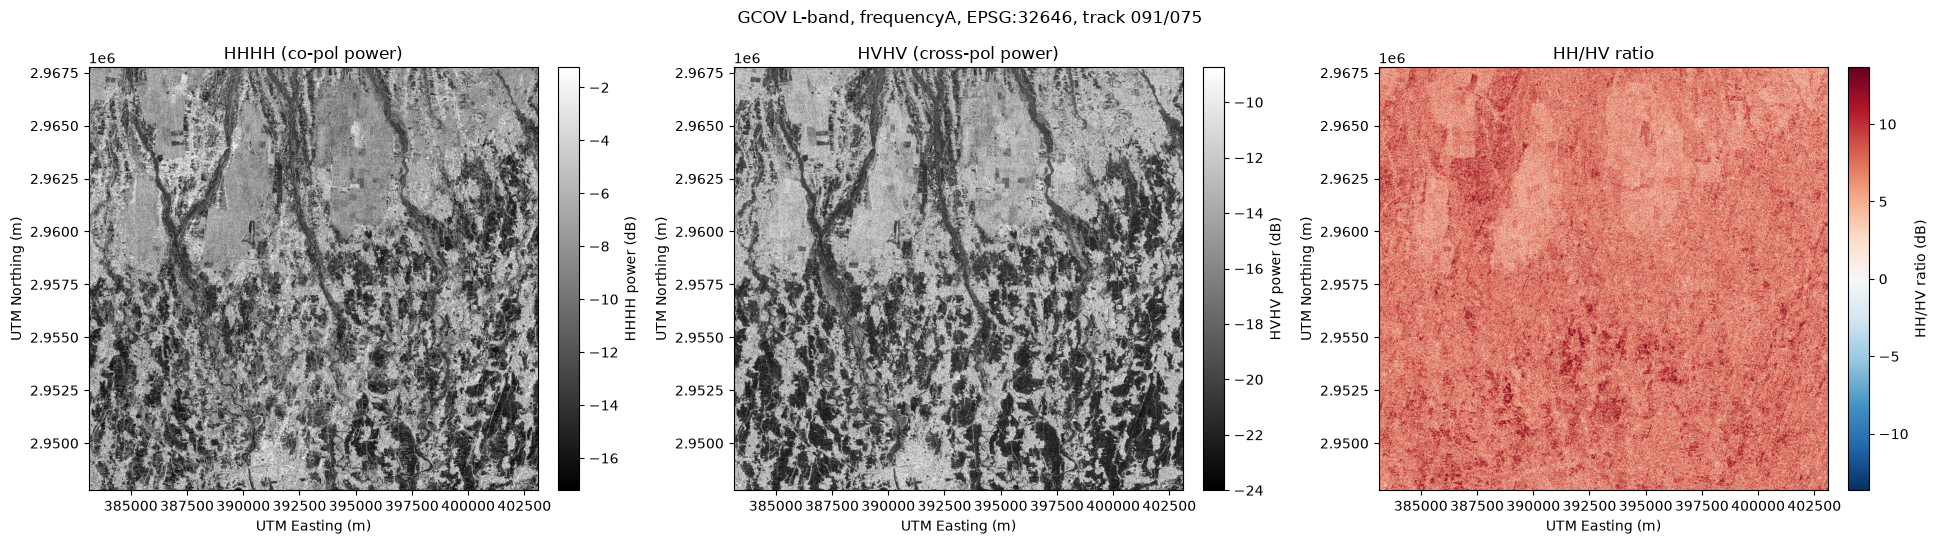

In [5]:
extent = [
    coords["x"][col_slice][0], coords["x"][col_slice][-1],
    coords["y"][row_slice][-1], coords["y"][row_slice][0],
]

fig, axes = viz.new_figure(ncols=3)
viz.imshow_amplitude(
    axes[0], hhhh_db, valid_mask=valid_mask, cmap="gray", extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="HHHH power (dB)",
    title="HHHH (co-pol power)",
)
viz.imshow_amplitude(
    axes[1], hvhv_db, valid_mask=valid_mask, cmap="gray", extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="HVHV power (dB)",
    title="HVHV (cross-pol power)",
)
viz.imshow_diverging(
    axes[2], ratio_db, valid_mask=valid_mask, extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="HH/HV ratio (dB)",
    title="HH/HV ratio",
)
fig.suptitle(f"GCOV L-band, frequencyA, EPSG:{coords['epsg']}, track 091/075")
fig.tight_layout()
plt.show()

## An illustrative threshold split (not a validated classification)

A common qualitative pattern: surfaces with more single/double-bounce (surface-like) scattering tend toward a higher HH/HV ratio, while more depolarizing (volume-like, e.g. dense vegetation canopy) scattering tends toward a lower ratio. Below we split the ratio map at its own median purely to illustrate the *mechanic* of turning a ratio into a two-class map — **the threshold is not derived from or checked against any reference land-cover data, so the two classes below should not be read as an actual land-cover classification.**

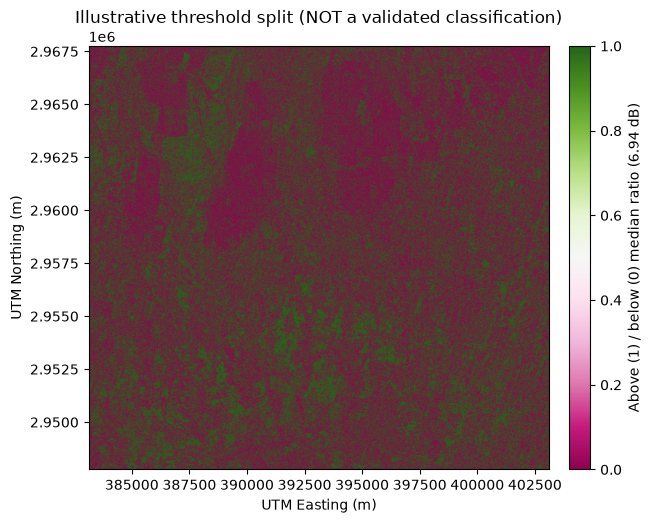

In [6]:
median_ratio = float(np.nanmedian(ratio_db))
class_map = np.where(valid_mask, (ratio_db > median_ratio).astype(float), np.nan)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
viz.imshow_masked(
    ax, class_map, valid_mask=valid_mask, cmap="PiYG", vmin=0, vmax=1, extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)",
    colorbar_label=f"Above (1) / below (0) median ratio ({median_ratio:.2f} dB)",
    title="Illustrative threshold split (NOT a validated classification)",
)
plt.show()

In [7]:
gcov_l.close()

## What real-world deployment would additionally require

- A validated reference land-cover/land-use map or field survey to define and check any classification thresholds — the median split above is arbitrary, chosen only to illustrate the mechanic.
- Radiometric terrain correction / normalization, since raw backscatter (and hence any ratio) is sensitive to local incidence angle and terrain slope, especially given this scene's elevation range (near sea level to several thousand meters).
- Multi-temporal or multi-frequency data (see Module 05) to disambiguate scattering mechanisms that a single-date HH/HV ratio alone cannot separate.
- For true polarimetric decomposition: quad-pol data (HH, HV, VH, VV) or, at minimum, a dual-pol product that includes the off-diagonal covariance term (see Module 06).